# Optimización Numérica con Algoritmos Genéticos (AGS)
## Ejercicio 3.10 - 1: Maximización de Función No Lineal Multimodal

---

### 1. Definición del Problema
Se requiere encontrar el valor de $x$ que maximiza la función continua no lineal:
$$f(x) = x \operatorname{sen}(10 \pi x) + 1 \quad \text{sujeto a} \quad x \in [0, 1]$$

#### Naturaleza Matemática y Espacio de Búsqueda
* **Multimodalidad:** La expresión sinusoidal $\operatorname{sen}(10 \pi x)$ completa 5 oscilaciones periódicas completas dentro del intervalo cerrado $[0, 1]$.
* **Picos locales vs. Óptimo global:** Los máximos locales del término sinusoidal se ubican en $x \in \{0.05, 0.25, 0.45, 0.65, 0.85\}$. Debido a que la función está modulada por el factor lineal creciente $x$, el pico de mayor magnitud ocurre en el último lóbulo:
  $$x^* = 0.85 \implies f(0.85) = 0.85 \cdot \operatorname{sen}(8.5 \pi) + 1 = 0.85 \cdot (1) + 1 = \mathbf{1.85}$$
* **Justificación de los Algoritmos Genéticos:** Un algoritmo tradicional basado en gradiente descendente o Newton-Raphson es altamente sensible a la semilla inicial y queda atrapado en los picos locales secundarios ($x = 0.05, 0.25, \dots$). El Algoritmo Genético Simple (AGS) realiza una exploración estocástica y paralela sobre una población de cromosomas, combinando esquemas exitosos (*building blocks*) para localizar el óptimo global sin requerir derivadas.

---

### 2. Estructura y Parámetros del Algoritmo
Siguiendo las pautas metodológicas de las secciones 3.3 a 3.8 del documento guía:

* **Longitud del cromosoma ($l = 16$ bits):** Permite discretizar el dominio continuo $[0, 1]$ en $2^{16} = 65.536$ intervalos, otorgando una precisión decimal superior a $\Delta x \approx 1.52 \times 10^{-5}$.
* **Tamaño de población ($K = 40$):** Cantidad de soluciones candidatas procesadas en simultáneo en cada generación.
* **Criterio de parada ($M = 80$ generaciones):** Límite generacional para asegurar la convergencia de la población.
* **Probabilidad de mutación ($p_m = 0.02$):** Tasa baja (2%) para preservar esquemas exitosos mientras se introduce variabilidad que previene la convergencia prematura.

---

### 3. Explicación de los Módulos del Código
1. `f_objetivo(x)`: Función matemática encargada de calcular el valor analítico $f(x)$ que actúa como la aptitud del individuo.
2. `genera(l, K)`: Inicializa la población como una matriz binaria de $K \times l$ mediante lanzamientos equiprobables de ceros y unos.
3. `decodifica(crom, l, xi, xf)`: Transforma la cadena binaria (genotipo) al valor real continuo (fenotipo) en el intervalo $[0, 1]$ mediante la ecuación de interpolación:
   $$x = x_i + \frac{x_f - x_i}{2^l - 1} \sum_{j=0}^{l-1} \text{crom}[j] \cdot 2^{l - 1 - j}$$
4. `eval_apt(pob, l)`: Evalúa el desempeño individual y normaliza las aptitudes para calcular la probabilidad de selección de cada cromosoma mediante la regla de la ruleta:
   $$p_i = \frac{f(x_i)}{\sum_{k=1}^K f(x_k)}$$
5. `seleccion(pob, probab)`: Aplica el operador darwiniano de selección proporcional con reemplazo, favoreciendo la reproducción de los individuos con mayor aptitud.
6. `cruce(pob_padres)`: Cruce simple monopunto donde se corta aleatoriamente la cadena en un punto $pt \in [1, l-1]$ para recombinar el material genético de los padres.
7. `mutacion(hijos, p_mut, l)`: Operador de exploración estocástica que invierte bits individuales ($0 \leftrightarrow 1$) con probabilidad $p_m$.
8. `graficar_resultados(...)`: Genera dos paneles: la visualización del espacio de búsqueda con las soluciones agrupadas en el pico global y la curva histórica de convergencia generacional.

Solución encontrada: x = 0.855360 con f(x) = 1.843263


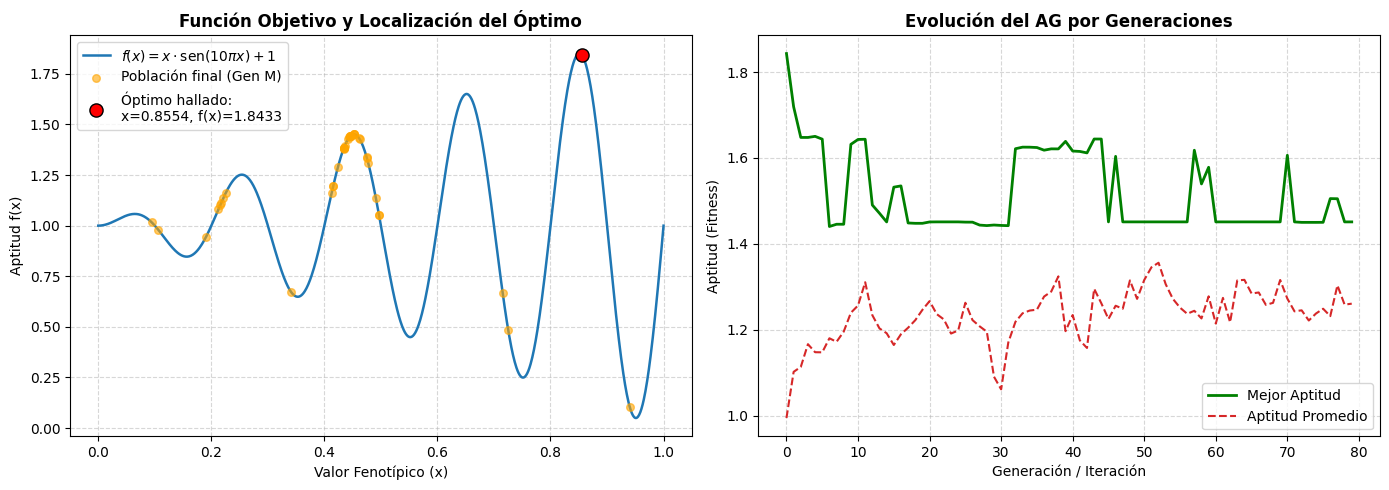

In [4]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------
# 1. Definición de la función objetivo (Ejercicio 3.10 - 1)
# -------------------------------------------------------------
def ecuacion(x):
    return x * np.sin(10 * np.pi * x) + 1

# -------------------------------------------------------------
# 2. Rutinas del Algoritmo Genético Simple (AGS)
# -------------------------------------------------------------
def genera(l, K):
    """Crea la población inicial aleatoria de K cromosomas de longitud l."""
    return [[random.randint(0, 1) for _ in range(l)] for _ in range(K)]

def decodifica(crom, l, xi=0.0, xf=1.0):
    """Mapea el cromosoma binario al dominio continuo [xi, xf]."""
    valor_decimal = sum(crom[i] * (2 ** (l - i - 1)) for i in range(l))
    max_val = (2 ** l) - 1
    return xi + ((xf - xi) / max_val) * valor_decimal

def eval_apt(pob, l):
    """Calcula las aptitudes individuales y las probabilidades de selección (ruleta)."""
    apt_crom = [ecuacion(decodifica(c, l)) for c in pob]
    apt_pob = sum(apt_crom)
    probab = [apt / apt_pob if apt_pob > 0 else 1.0 / len(pob) for apt in apt_crom]
    return apt_crom, probab

def seleccion(pob, probab):
    """Selección por ruleta proporcional a la aptitud."""
    return random.choices(pob, weights=probab, k=len(pob))

def cruce(pob_padres):
    """Cruce simple en un punto."""
    hijos = []
    k = len(pob_padres)
    for i in range(0, k - 1, 2):
        p1, p2 = pob_padres[i], pob_padres[i + 1]
        pt = random.randint(1, len(p1) - 1)
        hijos.append(p1[:pt] + p2[pt:])
        hijos.append(p2[:pt] + p1[pt:])
    if len(hijos) < k:
        hijos.append(pob_padres[-1])
    return hijos

def mutacion(hijos, p_mut, l):
    """Mutación puntual por inversión de bits con probabilidad p_mut."""
    k = len(hijos)
    total_bits = k * l
    n_mutaciones = int(total_bits * p_mut)
    for _ in range(n_mutaciones):
        idx = random.randint(0, total_bits - 1)
        individuo = idx // l
        gen = idx % l
        hijos[individuo][gen] = 1 - hijos[individuo][gen]
    return hijos

# -------------------------------------------------------------
# 3. Ejecución del AG con captura de métricas históricas
# -------------------------------------------------------------
def Alg_Genetico_Con_Historial(l=16, M=100, K=40, p_mut=0.02):
    pob = genera(l, K)

    hist_mejor_apt = []
    hist_prom_apt = []

    mejor_global_crom = None
    mejor_global_apt = -float('inf')

    for gen in range(M):
        apt_crom, probab = eval_apt(pob, l)

        # Registro estadístico de la generación
        mejor_gen_apt = max(apt_crom)
        prom_gen_apt = sum(apt_crom) / len(apt_crom)
        hist_mejor_apt.append(mejor_gen_apt)
        hist_prom_apt.append(prom_gen_apt)

        # Actualización del mejor absoluto
        if mejor_gen_apt > mejor_global_apt:
            mejor_global_apt = mejor_gen_apt
            mejor_global_crom = list(pob[apt_crom.index(mejor_gen_apt)])

        # Evolución a la siguiente generación
        padres = seleccion(pob, probab)
        hijos = cruce(padres)
        pob = mutacion(hijos, p_mut, l)

    x_optimo = decodifica(mejor_global_crom, l)
    poblacion_final_x = [decodifica(c, l) for c in pob]

    return x_optimo, mejor_global_apt, hist_mejor_apt, hist_prom_apt, poblacion_final_x

# -------------------------------------------------------------
# 4. Generación y Renderizado de Gráficas
# -------------------------------------------------------------
def graficar_resultados(x_optimo, mejor_apt, hist_mejor, hist_prom, pob_final_x):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Gráfica 1: Espacio de Búsqueda y Función f(x) ---
    x_vals = np.linspace(0, 1, 1000)
    y_vals = ecuacion(x_vals)

    ax1.plot(x_vals, y_vals, label=r"$f(x) = x \cdot \mathrm{sen}(10\pi x) + 1$", color="#1f77b4", linewidth=1.8)

    # Individuos finales de la población
    y_pob = [ecuacion(x) for x in pob_final_x]
    ax1.scatter(pob_final_x, y_pob, color="orange", alpha=0.6, s=30, label="Población final (Gen M)", zorder=3)

    # Mejor punto encontrado
    ax1.scatter([x_optimo], [mejor_apt], color="red", s=90, edgecolors="black",
                label=f"Óptimo hallado:\nx={x_optimo:.4f}, f(x)={mejor_apt:.4f}", zorder=4)

    ax1.set_title("Función Objetivo y Localización del Óptimo", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Valor Fenotípico (x)")
    ax1.set_ylabel("Aptitud f(x)")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc="upper left")

    # --- Gráfica 2: Curva de Convergencia (Evolución de Aptitud) ---
    generaciones = range(len(hist_mejor))
    ax2.plot(generaciones, hist_mejor, label="Mejor Aptitud", color="green", linewidth=2)
    ax2.plot(generaciones, hist_prom, label="Aptitud Promedio", color="#d62728", linestyle="--", linewidth=1.5)

    ax2.set_title("Evolución del AG por Generaciones", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Generación / Iteración")
    ax2.set_ylabel("Aptitud (Fitness)")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    random.seed(42)

    x_opt, f_opt, hist_m, hist_p, pob_fin_x = Alg_Genetico_Con_Historial(
        l=16, M=80, K=40, p_mut=0.02
    )

    print(f"Solución encontrada: x = {x_opt:.6f} con f(x) = {f_opt:.6f}")
    graficar_resultados(x_opt, f_opt, hist_m, hist_p, pob_fin_x)


## Ejercicio 3.10 - 2: Verdadera Democracia

---

### 1. Definición del Escenario Político y Problema
Como jefe de gobierno, se requiere garantizar la gobernabilidad en un congreso conformado por 5 partidos políticos ($P_1, P_2, P_3, P_4, P_5$) que suman un total de 50 curules distribuidas de forma no uniforme.
Para lograr el tránsito de los proyectos legislativos, el poder burocrático (conformado por 50 entidades estatales con pesos políticos de 1 a 100 puntos) debe repartirse proporcionalmente según la representación de cada bancada[cite: 3].

#### Naturaleza Combinatoria (Problema NP)
* **Espacio de búsqueda:** Se tienen 50 entidades estatales independientes y cada una puede asignarse a cualquiera de los 5 partidos[cite: 3]. El número de posibles combinaciones es:
  $$5^{50} \approx 8.88 \times 10^{34} \text{ asignaciones posibles}$$
* Como se expone en las secciones 3.6 y 3.7 del documento para problemas NP-Completos (como el de la mochila), evaluar este volumen de soluciones por fuerza bruta es computacionalmente intratable[cite: 3]. Los Algoritmos Genéticos permiten explorar estocásticamente el espacio y hallar configuraciones de asignación óptimas o cuasi-óptimas en pocos segundos[cite: 3].

---

### 2. Modelado Matemático y Representación Cromosómica

Siguiendo la metodología de diseño de la sección 3.8 del documento[cite: 3]:

1. **Metas Proporcionales de Poder:**
   * Sea $C_j$ el número de curules del partido $j$ ($\sum_{j=0}^{4} C_j = 50$)[cite: 3].
   * Sea $p_i$ el peso político de la entidad estatal $i \in \{0, \dots, 49\}$ ($p_i \in [1, 100]$)[cite: 3].
   * Poder total en disputa: $P_{\text{total}} = \sum_{i=0}^{49} p_i$[cite: 3].
   * Poder meta del partido $j$:
     $$T_j = \left(\frac{C_j}{50}\right) \cdot P_{\text{total}}$$

2. **Genotipo vs. Fenotipo (La Matriz de Poder):**
   * **Genotipo (Cromosoma):** Vector de longitud $l = 50$ con números enteros en $\{0, 1, 2, 3, 4\}$[cite: 3]. La posición $i$ representa la entidad $i$, y el valor entero indica el partido al que fue asignada[cite: 3]. Esta codificación satisface directamente la restricción de que cada entidad se asigna a un único partido[cite: 3].
   * **Fenotipo (Matriz de Poder $M$):** Matriz binaria de dimensiones $5 \times 50$ donde[cite: 3]:
     $$M_{j, i} = \begin{cases} 1 & \text{si el partido } j \text{ controla la entidad } i \\ 0 & \text{en caso contrario} \end{cases}$$

3. **Función de Aptitud (Fitness):**
   * Para cada individuo se calcula el poder acumulado por cada partido:
     $$S_j = \sum_{i=0}^{49} M_{j, i} \cdot p_i$$
   * Se evalúa la discrepancia absoluta total respecto a la meta electoral:
     $$\text{Error} = \sum_{j=0}^{4} |S_j - T_j|$$
   * Como se busca minimizar el error, la aptitud se define inversamente proporcional a la discrepancia:
     $$\text{Aptitud} = \frac{1000}{1 + \text{Error}}$$

---

### 3. Operadores Genéticos y Parámetros
* **Población ($K = 60$):** Cantidad de soluciones candidatas procesadas en cada generación[cite: 3].
* **Criterio de parada ($M = 150$):** Número de generaciones para consolidar los esquemas exitosos (*building blocks*)[cite: 3].
* **Selección por Ruleta:** Probabilidad de reproducción proporcional a la aptitud individual $p_k = \frac{\text{Apt}_k}{\sum \text{Apt}}$[cite: 3].
* **Cruce Monopunto:** Intercambio de bloques de asignación entre parejas de padres a partir de un corte aleatorio $pt \in [1, 49]$[cite: 3].
* **Mutación ($p_m = 0.03$):** Probabilidad del 3% por gen para reasignar una entidad a otro partido al azar, evitando estancamientos en óptimos locales[cite: 3].

        RESULTADOS DEL REPARTO DE PODER (VERDADERA DEMOCRACIA)
Poder Político Total disponible: 2358 puntos.
---------------------------------------------------------------------------
Partido    | Curules  | % Curules  | Poder Ideal  | Poder AG   | Diferencia
---------------------------------------------------------------------------
Partido 1  | 2        |      4.0% |        94.32 |         95 |      +0.68
Partido 2  | 6        |     12.0% |       282.96 |        278 |      -4.96
Partido 3  | 33       |     66.0% |      1556.28 |       1561 |      +4.72
Partido 4  | 7        |     14.0% |       330.12 |        328 |      -2.12
Partido 5  | 2        |      4.0% |        94.32 |         96 |      +1.68
---------------------------------------------------------------------------
Error o Discrepancia Total acumulada: 14.16 puntos.
Dimensiones de la Matriz de Poder: (5, 50) (5 Partidos x 50 Entidades)
Validación de asignación única por entidad: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]... (todas suma

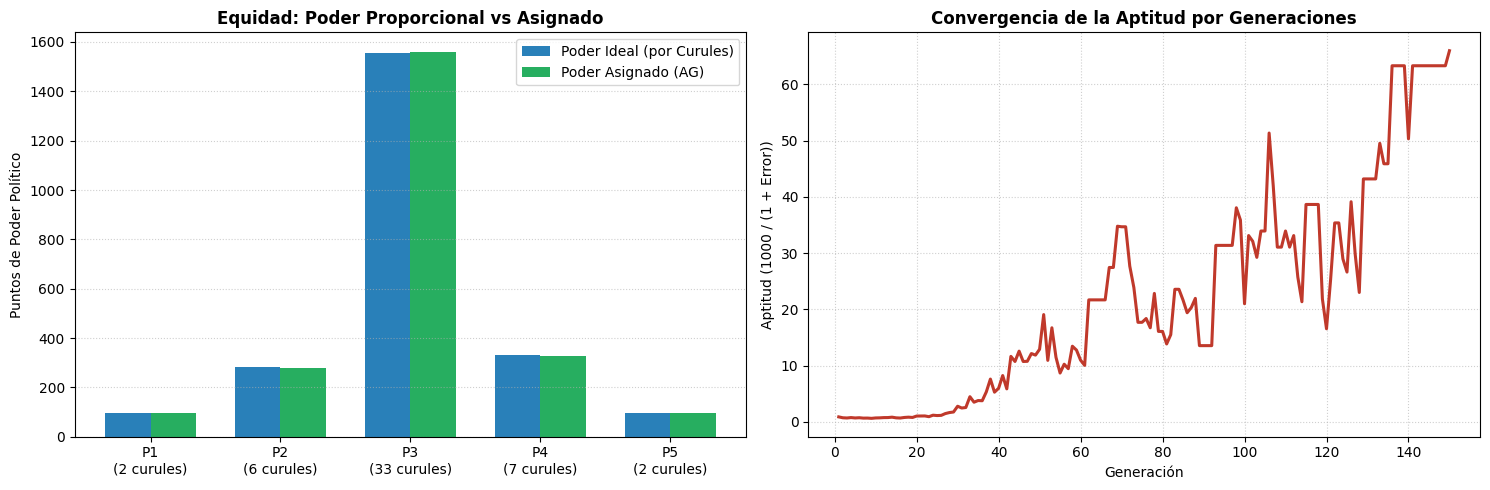

In [5]:
# ==============================================================================
# ALGORITMO GENÉTICO: DISTRIBUCIÓN DE PODER POLÍTICO (VERDADERA DEMOCRACIA)
# Ejercicio 3.10 - 2: Asignación proporcional de 50 entidades a 5 partidos
# ==============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. CONFIGURACIÓN DEL ESCENARIO POLÍTICO
# ------------------------------------------------------------------------------
def configurar_escenario_politico():
    """
    1. Genera distribución no uniforme de 50 curules entre 5 partidos.
    2. Genera 50 entidades estatales con pesos de poder entre 1 y 100 puntos.
    3. Calcula el poder meta de cada bancada.
    """
    # Distribución no uniforme garantizada mediante particiones aleatorias
    cortes = sorted(random.sample(range(1, 50), 4))
    curules = [
        cortes[0],
        cortes[1] - cortes[0],
        cortes[2] - cortes[1],
        cortes[3] - cortes[2],
        50 - cortes[3]
    ]

    # 50 entidades estatales con pesos entre 1 y 100
    pesos_entidades = [random.randint(1, 100) for _ in range(50)]

    poder_total = sum(pesos_entidades)
    porcentaje_curules = [c / 50.0 for c in curules]
    poder_meta = [p * poder_total for p in porcentaje_curules]

    return curules, pesos_entidades, poder_total, poder_meta

# ------------------------------------------------------------------------------
# 2. RUTINAS DEL ALGORITMO GENÉTICO (SECCIONES 3.3, 3.5 Y 3.8)
# ------------------------------------------------------------------------------
def genera_poblacion(K, l=50, n_partidos=5):
    """Crea K cromosomas donde cada gen almacena el partido asignado (0 a 4)."""
    return [[random.randint(0, n_partidos - 1) for _ in range(l)] for _ in range(K)]

def construir_matriz_poder(cromosoma, n_partidos=5, n_entidades=50):
    """
    Decodifica el genotipo en la Matriz de Poder binaria M (5 x 50).
    M[j, i] = 1 si la entidad i pertenece al partido j, 0 de lo contrario.
    """
    matriz = np.zeros((n_partidos, n_entidades), dtype=int)
    for entidad_idx, partido_idx in enumerate(cromosoma):
        matriz[partido_idx, entidad_idx] = 1
    return matriz

def evaluar_individuo(cromosoma, pesos, poder_meta, n_partidos=5):
    """Calcula el poder recibido por partido y la aptitud (Fitness)."""
    poder_asignado = [0] * n_partidos
    for entidad_idx, partido_idx in enumerate(cromosoma):
        poder_asignado[partido_idx] += pesos[entidad_idx]

    error = sum(abs(poder_asignado[j] - poder_meta[j]) for j in range(n_partidos))
    aptitud = 1000.0 / (1.0 + error)
    return aptitud, poder_asignado, error

def eval_apt(poblacion, pesos, poder_meta):
    """Calcula aptitudes individuales y probabilidades por ruleta."""
    aptitudes = []
    for c in poblacion:
        apt, _, _ = evaluar_individuo(c, pesos, poder_meta)
        aptitudes.append(apt)

    total_apt = sum(aptitudes)
    probab = [a / total_apt if total_apt > 0 else 1.0 / len(poblacion) for a in aptitudes]
    return aptitudes, probab

def seleccion(poblacion, probab):
    """Selección por ruleta proporcional con reemplazo."""
    return random.choices(poblacion, weights=probab, k=len(poblacion))

def cruce(padres, l=50):
    """Cruce simple en un punto."""
    hijos = []
    K = len(padres)
    for i in range(0, K - 1, 2):
        p1, p2 = padres[i], padres[i + 1]
        pt = random.randint(1, l - 1)
        hijos.append(p1[:pt] + p2[pt:])
        hijos.append(p2[:pt] + p1[pt:])
    if len(hijos) < K:
        hijos.append(padres[-1])
    return hijos

def mutacion(hijos, p_mut=0.03, l=50, n_partidos=5):
    """Mutación puntual: asigna una entidad a otro partido con probabilidad p_mut."""
    for individuo in hijos:
        for gen_idx in range(l):
            if random.random() < p_mut:
                individuo[gen_idx] = random.randint(0, n_partidos - 1)
    return hijos

# ------------------------------------------------------------------------------
# 3. CICLO GENERACIONAL DEL AG
# ------------------------------------------------------------------------------
def ejecutar_ag_democracia(pesos, poder_meta, K=60, M=150, p_mut=0.03):
    """Ejecuta el proceso evolutivo durante M generaciones."""
    pob = genera_poblacion(K)
    historial_mejor_apt = []
    mejor_cromosoma = None
    mejor_apt_global = -float('inf')

    for gen in range(M):
        aptitudes, probab = eval_apt(pob, pesos, poder_meta)

        mejor_gen = max(aptitudes)
        historial_mejor_apt.append(mejor_gen)

        if mejor_gen > mejor_apt_global:
            mejor_apt_global = mejor_gen
            idx_mejor = aptitudes.index(mejor_gen)
            mejor_cromosoma = list(pob[idx_mejor])

        padres = seleccion(pob, probab)
        descendencia = cruce(padres)
        pob = mutacion(descendencia, p_mut)

    return mejor_cromosoma, historial_mejor_apt

# ------------------------------------------------------------------------------
# 4. VISUALIZACIÓN GRÁFICA COMPLETA
# ------------------------------------------------------------------------------
def graficar_distribucion_y_convergencia(curules, poder_meta, poder_asignado, hist_apt):
    """Muestra la comparación de poder asignado vs ideal y la convergencia del AG."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    partidos = [f"P{i+1}\n({curules[i]} curules)" for i in range(5)]
    x = np.arange(len(partidos))
    ancho = 0.35

    # Gráfica 1: Comparación de equidad en barras
    ax1.bar(x - ancho/2, poder_meta, ancho, label="Poder Ideal (por Curules)", color="#2980b9")
    ax1.bar(x + ancho/2, poder_asignado, ancho, label="Poder Asignado (AG)", color="#27ae60")
    ax1.set_title("Equidad: Poder Proporcional vs Asignado", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Puntos de Poder Político")
    ax1.set_xticks(x)
    ax1.set_xticklabels(partidos)
    ax1.legend()
    ax1.grid(axis='y', linestyle=':', alpha=0.6)

    # Gráfica 2: Curva de convergencia generacional
    generaciones = range(1, len(hist_apt) + 1)
    ax2.plot(generaciones, hist_apt, color="#c0392b", linewidth=2.2)
    ax2.set_title("Convergencia de la Aptitud por Generaciones", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Generación")
    ax2.set_ylabel("Aptitud (1000 / (1 + Error))")
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 5. EJECUCIÓN PRINCIPAL
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    random.seed(42)
    np.random.seed(42)

    curules, pesos, poder_total, poder_meta = configurar_escenario_politico()
    mejor_crom, hist_apt = ejecutar_ag_democracia(pesos, poder_meta, K=60, M=150, p_mut=0.03)

    _, poder_asignado, error_final = evaluar_individuo(mejor_crom, pesos, poder_meta)
    matriz_poder = construir_matriz_poder(mejor_crom)

    print("=" * 75)
    print("        RESULTADOS DEL REPARTO DE PODER (VERDADERA DEMOCRACIA)")
    print("=" * 75)
    print(f"Poder Político Total disponible: {poder_total} puntos.")
    print("-" * 75)
    print(f"{'Partido':<10} | {'Curules':<8} | {'% Curules':<10} | {'Poder Ideal':<12} | {'Poder AG':<10} | {'Diferencia':<10}")
    print("-" * 75)
    for j in range(5):
        pct = (curules[j] / 50.0) * 100
        dif = poder_asignado[j] - poder_meta[j]
        print(f"Partido {j+1:<2} | {curules[j]:<8} | {pct:>8.1f}% | {poder_meta[j]:>12.2f} | {poder_asignado[j]:>10} | {dif:>+10.2f}")
    print("-" * 75)
    print(f"Error o Discrepancia Total acumulada: {error_final:.2f} puntos.")
    print(f"Dimensiones de la Matriz de Poder: {matriz_poder.shape} (5 Partidos x 50 Entidades)")
    print(f"Validación de asignación única por entidad: {matriz_poder.sum(axis=0).tolist()[:10]}... (todas suman 1)")
    print("=" * 75)

    # Renderizado gráfico
    graficar_distribucion_y_convergencia(curules, poder_meta, poder_asignado, hist_apt)

# 1. Análisis del Problema y Formulación Matemática

El Ejercicio 3 corresponde al **Despacho Óptimo de Energía Eléctrica**. Es un problema de transporte con costos de generación, donde se busca decidir cuánta energía enviar desde cada planta hacia cada ciudad minimizando el costo total.

## A. Balance de Oferta y Demanda

### Capacidades de generación

| Planta | Capacidad |
|---|---:|
| Planta C | 3 GW/día |
| Planta B | 6 GW/día |
| Planta M | 5 GW/día |
| Planta BA | 4 GW/día |

La capacidad total disponible es:

$$
3 + 6 + 5 + 4 = 18 \ \text{GW/día}
$$

### Demandas de las ciudades

| Ciudad | Demanda |
|---|---:|
| Cali | 4 GW/día |
| Bogotá | 3 GW/día |
| Medellín | 5 GW/día |
| Barranquilla | 3 GW/día |

La demanda total es:

$$
4 + 3 + 5 + 3 = 15 \ \text{GW/día}
$$

Como la oferta total es mayor que la demanda total:

$$
18 > 15
$$

el sistema tiene una holgura de:

$$
18 - 15 = 3 \ \text{GW/día}
$$

Por tanto, no es necesario utilizar toda la capacidad de generación.

## B. Costos Involucrados

### Costo de transporte

La matriz de costos de transporte es:

$$
C_{\text{trans}} =
\begin{bmatrix}
1 & 4 & 3 & 6 \\
4 & 1 & 4 & 5 \\
3 & 4 & 1 & 4 \\
6 & 5 & 4 & 1
\end{bmatrix}
$$

Cada fila representa una planta y cada columna una ciudad.

### Costo de generación

| Planta | Costo de generación |
|---|---:|
| Planta C | 680 $/kWh |
| Planta B | 720 $/kWh |
| Planta M | 660 $/kWh |
| Planta BA | 750 $/kWh |

Para comparar los costos dentro del algoritmo, se puede usar una escala normalizada. Esto evita que el costo de generación domine completamente sobre el costo de transporte.

## C. Modelo Matemático

Sea $x_{ij}$ la cantidad de energía enviada desde la planta $i$ hacia la ciudad $j$, medida en GW/día.

La función objetivo es:

$$
\min Z =
\sum_{i=1}^{4}
\sum_{j=1}^{4}
\left(
C_{\text{trans},ij} + C_{\text{gen},i}
\right)x_{ij}
$$

Sujeto a:

### Restricción de capacidad

$$
\sum_{j=1}^{4} x_{ij} \leq \text{Capacidad}_i
\qquad i = 1,2,3,4
$$

### Restricción de demanda

$$
\sum_{i=1}^{4} x_{ij} = \text{Demanda}_j
\qquad j = 1,2,3,4
$$

### Restricción de no negatividad

$$
x_{ij} \geq 0
$$

Como se trabaja con GW enteros:

$$
x_{ij} \in \{0,1,2,\dots\}
$$

# 2. Diseño del Algoritmo Genético

Un **algoritmo genético** es una técnica de optimización inspirada en la evolución natural. Trabaja con una población de posibles soluciones, evalúa su calidad y genera nuevas soluciones mediante selección, cruce y mutación.

## A. Codificación del cromosoma

Cada solución se representa como una matriz de despacho:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34} \\
x_{41} & x_{42} & x_{43} & x_{44}
\end{bmatrix}
$$

Esta matriz se convierte en un vector de 16 genes:

$$
l = 16
$$

Cada gen representa la energía enviada por una ruta planta-ciudad.

## B. Manejo de restricciones por penalización

Si una solución supera la capacidad máxima de una planta o no satisface exactamente la demanda de una ciudad, se le agrega una penalización al costo total.

Así, las soluciones que incumplen restricciones tienen menor probabilidad de continuar en el proceso evolutivo.

## C. Función de aptitud

Como el objetivo es minimizar el costo, la aptitud se define de forma inversa:

$$
\text{Aptitud} =
\frac{1}
{1 + Z + \lambda_1 P_{\text{capacidad}} + \lambda_2 P_{\text{demanda}}}
$$

Donde:

$$
P_{\text{capacidad}}
$$

representa el exceso sobre las capacidades máximas, y:

$$
P_{\text{demanda}}
$$

representa el error en el cumplimiento de las demandas.

Los coeficientes $\lambda_1$ y $\lambda_2$ controlan el peso de las penalizaciones.

## D. Operadores genéticos

| Operador | Descripción |
|---|---|
| Selección por ruleta | Da mayor probabilidad de reproducción a los individuos con mejor aptitud. |
| Cruce de un punto | Combina dos cromosomas padres para generar descendientes. |
| Mutación | Modifica aleatoriamente algunos genes para explorar nuevas soluciones. |
| Elitismo | Conserva el mejor individuo de cada generación. |

## E. Criterio de parada

El algoritmo se ejecuta durante un número fijo de generaciones. Al finalizar, se toma el mejor individuo encontrado como la solución aproximada del problema.

RESULTADOS DEL DESPACHO ÓPTIMO DE ENERGÍA CON ALGORITMO GENÉTICO
Costo total normalizado: 128.10
Aptitud final: 0.00774593
Exceso sobre capacidades: 0 GW
Error sobre demandas: 0 GW
-------------------------------------------------------------------------------------
Planta       | Generado   | Capacidad  | Cali     | Bogotá   | Medellín  | Barranq. 
-------------------------------------------------------------------------------------
Planta C     | 2          | 3          | 2        | 0        | 0         | 0        
Planta B     | 5          | 6          | 1        | 3        | 1         | 0        
Planta M     | 5          | 5          | 1        | 0        | 4         | 0        
Planta BA    | 3          | 4          | 0        | 0        | 0         | 3        
-------------------------------------------------------------------------------------
Recibido     |            |            | 4        | 3        | 5         | 3        
Demanda      |            |            | 4        |

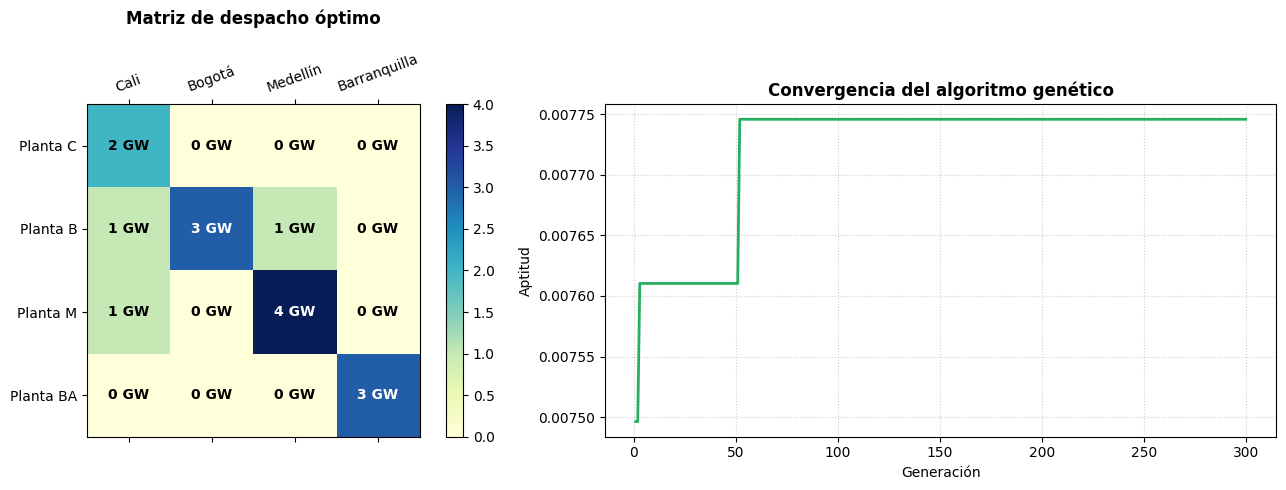

In [7]:
# ==============================================================================
# ALGORITMO GENÉTICO: DESPACHO ÓPTIMO DE ENERGÍA ELÉCTRICA
# Optimización de generación y transporte 4 plantas -> 4 ciudades
# ==============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. DATOS DEL PROBLEMA
# ------------------------------------------------------------------------------

nombres_plantas = ["Planta C", "Planta B", "Planta M", "Planta BA"]
nombres_ciudades = ["Cali", "Bogotá", "Medellín", "Barranquilla"]

# Capacidades máximas por planta en GW/día
capacidades = np.array([3, 6, 5, 4])

# Demandas por ciudad en GW/día
demandas = np.array([4, 3, 5, 3])

# Costos de transporte por GW
costos_transporte = np.array([
    [1, 4, 3, 6],
    [4, 1, 4, 5],
    [3, 4, 1, 4],
    [6, 5, 4, 1]
])

# Costos de generación en $/kWh
costos_gen_kwh = np.array([680, 720, 660, 750])

# Escala normalizada para que generación y transporte sean comparables en el AG
FACTOR_ESCALA = 0.01
costos_gen_gw = costos_gen_kwh * FACTOR_ESCALA

# Penalizaciones
PENAL_CAPACIDAD = 1000.0
PENAL_DEMANDA = 3000.0

# ------------------------------------------------------------------------------
# 2. GENERACIÓN DE INDIVIDUOS
# ------------------------------------------------------------------------------

def genera_individuo():
    """
    Genera un cromosoma 4x4 aplanado.
    Cada columna representa una ciudad y se reparte su demanda entre plantas.
    """
    matriz = np.zeros((4, 4), dtype=int)

    for j in range(4):
        restante = demandas[j]

        while restante > 0:
            i = random.randint(0, 3)
            asignar = random.randint(1, restante)
            matriz[i, j] += asignar
            restante -= asignar

    return matriz.flatten().tolist()


def genera_poblacion(tamano):
    """Genera una población inicial."""
    return [genera_individuo() for _ in range(tamano)]

# ------------------------------------------------------------------------------
# 3. EVALUACIÓN DE SOLUCIONES
# ------------------------------------------------------------------------------

def evaluar_despacho(cromosoma):
    """
    Evalúa un cromosoma calculando:
    - costo de transporte
    - costo de generación
    - penalización por incumplir restricciones
    - aptitud o fitness
    """
    matriz = np.array(cromosoma).reshape((4, 4))

    generado_por_planta = np.sum(matriz, axis=1)
    recibido_por_ciudad = np.sum(matriz, axis=0)

    costo_trans = np.sum(matriz * costos_transporte)
    costo_gen = np.sum(generado_por_planta * costos_gen_gw)

    costo_total = costo_trans + costo_gen

    exceso_capacidad = np.sum(np.maximum(0, generado_por_planta - capacidades))
    error_demanda = np.sum(np.abs(recibido_por_ciudad - demandas))

    penalizacion = (
        exceso_capacidad * PENAL_CAPACIDAD +
        error_demanda * PENAL_DEMANDA
    )

    valor_objetivo = costo_total + penalizacion

    aptitud = 1.0 / (1.0 + valor_objetivo)

    return aptitud, costo_total, exceso_capacidad, error_demanda, matriz


def eval_apt(poblacion):
    """Calcula aptitudes y probabilidades de selección."""
    aptitudes = []

    for cromosoma in poblacion:
        aptitud, _, _, _, _ = evaluar_despacho(cromosoma)
        aptitudes.append(aptitud)

    suma_aptitudes = sum(aptitudes)

    if suma_aptitudes == 0:
        probabilidades = [1 / len(poblacion)] * len(poblacion)
    else:
        probabilidades = [apt / suma_aptitudes for apt in aptitudes]

    return aptitudes, probabilidades

# ------------------------------------------------------------------------------
# 4. OPERADORES GENÉTICOS
# ------------------------------------------------------------------------------

def seleccion_ruleta(poblacion, probabilidades):
    """Selecciona individuos usando ruleta proporcional."""
    return random.choices(poblacion, weights=probabilidades, k=len(poblacion))


def cruce(padres):
    """Cruce de un punto para cromosomas de 16 genes."""
    hijos = []
    tamano = len(padres)

    for i in range(0, tamano - 1, 2):
        padre1 = padres[i]
        padre2 = padres[i + 1]

        punto = random.randint(1, 15)

        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]

        hijos.append(hijo1)
        hijos.append(hijo2)

    if len(hijos) < tamano:
        hijos.append(padres[-1])

    return hijos


def mutacion(hijos, p_mut=0.04):
    """Mutación discreta: aumenta o disminuye aleatoriamente un gen."""
    for individuo in hijos:
        for i in range(16):
            if random.random() < p_mut:
                cambio = random.choice([-1, 1])
                individuo[i] = max(0, individuo[i] + cambio)

    return hijos

# ------------------------------------------------------------------------------
# 5. ALGORITMO GENÉTICO PRINCIPAL
# ------------------------------------------------------------------------------

def optimizar_despacho_energia(tamano_pob=80, generaciones=300, p_mut=0.04):
    poblacion = genera_poblacion(tamano_pob)

    historial_aptitud = []
    historial_costo = []

    mejor_cromosoma = None
    mejor_aptitud_global = -float("inf")

    for gen in range(generaciones):
        aptitudes, probabilidades = eval_apt(poblacion)

        mejor_aptitud_gen = max(aptitudes)
        indice_mejor = aptitudes.index(mejor_aptitud_gen)

        apt, costo_total, exceso_cap, error_dem, matriz = evaluar_despacho(
            poblacion[indice_mejor]
        )

        historial_aptitud.append(mejor_aptitud_gen)
        historial_costo.append(costo_total)

        if mejor_aptitud_gen > mejor_aptitud_global:
            mejor_aptitud_global = mejor_aptitud_gen
            mejor_cromosoma = list(poblacion[indice_mejor])

        # Elitismo: se conserva el mejor individuo de la generación
        elite = list(poblacion[indice_mejor])

        padres = seleccion_ruleta(poblacion, probabilidades)
        hijos = cruce(padres)
        poblacion = mutacion(hijos, p_mut)

        # Reemplazar el peor individuo por la elite
        nuevas_aptitudes, _ = eval_apt(poblacion)
        indice_peor = nuevas_aptitudes.index(min(nuevas_aptitudes))
        poblacion[indice_peor] = elite

    return mejor_cromosoma, historial_aptitud, historial_costo

# ------------------------------------------------------------------------------
# 6. VISUALIZACIÓN
# ------------------------------------------------------------------------------

def graficar_resultados(matriz_optima, historial_aptitud):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    mapa = ax1.matshow(matriz_optima, cmap="YlGnBu")
    fig.colorbar(mapa, ax=ax1, fraction=0.046, pad=0.04)

    for i in range(4):
        for j in range(4):
            ax1.text(
                j, i,
                f"{matriz_optima[i, j]} GW",
                ha="center",
                va="center",
                color="black" if matriz_optima[i, j] < 3 else "white",
                fontweight="bold"
            )

    ax1.set_xticks(range(4))
    ax1.set_yticks(range(4))
    ax1.set_xticklabels(nombres_ciudades, rotation=20)
    ax1.set_yticklabels(nombres_plantas)
    ax1.set_title("Matriz de despacho óptimo", fontweight="bold", pad=20)

    ax2.plot(
        range(1, len(historial_aptitud) + 1),
        historial_aptitud,
        color="#27ae60",
        linewidth=2
    )

    ax2.set_title("Convergencia del algoritmo genético", fontweight="bold")
    ax2.set_xlabel("Generación")
    ax2.set_ylabel("Aptitud")
    ax2.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 7. EJECUCIÓN
# ------------------------------------------------------------------------------

random.seed(42)
np.random.seed(42)

mejor_cromosoma, historial_aptitud, historial_costo = optimizar_despacho_energia(
    tamano_pob=80,
    generaciones=300,
    p_mut=0.04
)

aptitud_final, costo_final, exceso_cap, error_dem, matriz_optima = evaluar_despacho(
    mejor_cromosoma
)

print("=" * 85)
print("RESULTADOS DEL DESPACHO ÓPTIMO DE ENERGÍA CON ALGORITMO GENÉTICO")
print("=" * 85)

print(f"Costo total normalizado: {costo_final:.2f}")
print(f"Aptitud final: {aptitud_final:.8f}")
print(f"Exceso sobre capacidades: {exceso_cap} GW")
print(f"Error sobre demandas: {error_dem} GW")

print("-" * 85)
print(
    f"{'Planta':<12} | {'Generado':<10} | {'Capacidad':<10} | "
    f"{'Cali':<8} | {'Bogotá':<8} | {'Medellín':<9} | {'Barranq.':<9}"
)
print("-" * 85)

for i in range(4):
    generado = np.sum(matriz_optima[i, :])

    print(
        f"{nombres_plantas[i]:<12} | {generado:<10} | {capacidades[i]:<10} | "
        f"{matriz_optima[i, 0]:<8} | {matriz_optima[i, 1]:<8} | "
        f"{matriz_optima[i, 2]:<9} | {matriz_optima[i, 3]:<9}"
    )

print("-" * 85)

print(
    f"{'Recibido':<12} | {'':<10} | {'':<10} | "
    f"{np.sum(matriz_optima[:, 0]):<8} | {np.sum(matriz_optima[:, 1]):<8} | "
    f"{np.sum(matriz_optima[:, 2]):<9} | {np.sum(matriz_optima[:, 3]):<9}"
)

print(
    f"{'Demanda':<12} | {'':<10} | {'':<10} | "
    f"{demandas[0]:<8} | {demandas[1]:<8} | "
    f"{demandas[2]:<9} | {demandas[3]:<9}"
)

print("=" * 85)

graficar_resultados(matriz_optima, historial_aptitud)

# Algoritmos Genéticos Aplicados a la Síntesis y Reconstrucción de Imágenes
## Ejercicio 3.10 - 4: Evolución de Matrices RGB hacia una Imagen Objetivo

---

### 1. Formulación del Problema
Se busca hacer evolucionar una población de $K = 50$ matrices generadas aleatoriamente de dimensiones $120 \times 180$ con números enteros en el intervalo $[0, 255]$, representadas como imágenes a color RGB, hasta aproximar progresivamente una imagen objetivo arbitraria.

### 2. Especificaciones de Diseño
* **Población ($K = 50$):** Matrices bidimensionales por canal (tensor de forma $120 \times 180 \times 3$).
* **Función de Aptitud:** Basada en la distancia entre la imagen generada y la imagen objetivo calculada mediante el Error Cuadrático Medio (MSE):
  $$\text{MSE} = \frac{1}{N} \sum (I_{\text{candidato}} - I_{\text{objetivo}})^2, \quad \text{Aptitud} = \frac{10^6}{1 + \text{MSE}}$$
* **Operador de Selección:** Combinación de Selección Elitista (preservación directa de los mejores genotipos) y Selección por Torneo/Ruleta.
* **Operador de Cruce:** Cruce en máscara/bloque bidimensional entre pares de progenitores.
* **Operador de Mutación:** Perturbación estocástica de intensidad con probabilidad controlada $p_m$.

Generación   1/250 -> MSE: 14082.92 | Similitud aprox: 78.34%
Generación  25/250 -> MSE: 13565.21 | Similitud aprox: 79.14%
Generación  75/250 -> MSE: 13244.33 | Similitud aprox: 79.63%
Generación 150/250 -> MSE: 12961.22 | Similitud aprox: 80.07%
Generación 250/250 -> MSE: 12575.10 | Similitud aprox: 80.66%


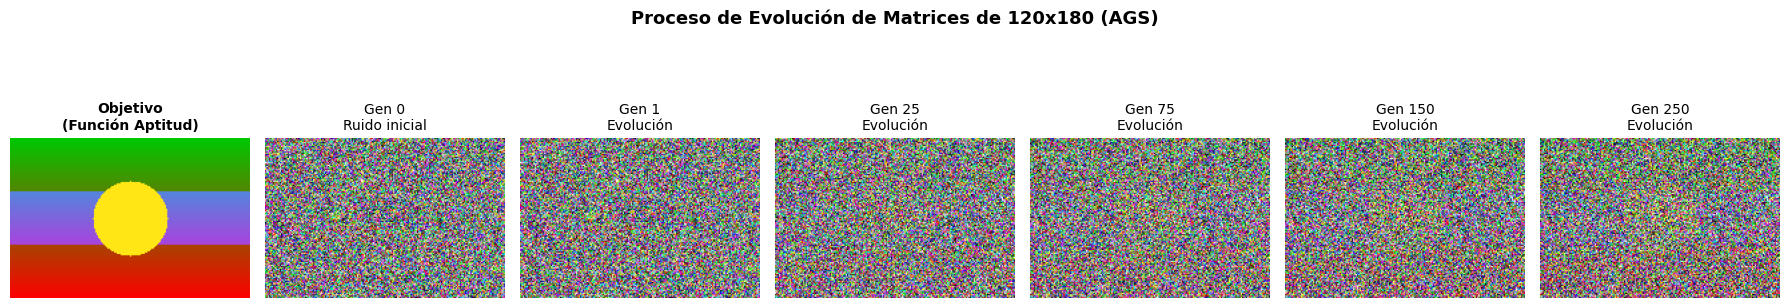

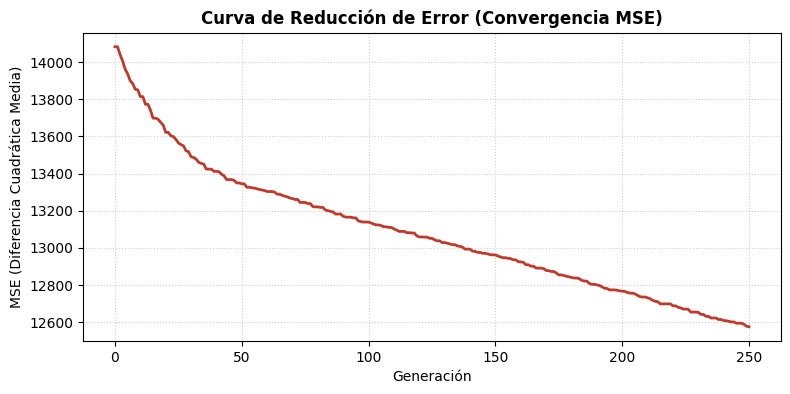

In [9]:

# Ejercicio 3.10 - 4: Población de 50 matrices (120x180x3) con valores en [0, 255]
# ==============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. PARÁMETROS GENERALES Y GENERACIÓN DE LA IMAGEN OBJETIVO
# ------------------------------------------------------------------------------
FILAS = 120
COLUMNAS = 180
CANALES = 3
K_POBLACION = 50
GENERACIONES = 250
P_MUTACION = 0.03
TASA_ELITISMO = 0.10  # 10% mejores individuos preservados intactos

def crear_imagen_objetivo(alto=120, ancho=180):
    """
    Crea una imagen objetivo sintética RGB nítida (120x180x3).
    (También puede reemplazarse por cualquier imagen real con plt.imread).
    """
    img = np.zeros((alto, ancho, 3), dtype=np.uint8)
    # Fondo degradado
    for y in range(alto):
        img[y, :, 0] = int(255 * (y / alto))        # Canal Rojo
        img[y, :, 1] = int(200 * (1 - y / alto))    # Canal Verde
    # Franja horizontal azul
    img[40:80, :, 2] = 220
    # Círculo / Disco central amarillo
    centro_y, centro_x, radio = alto // 2, ancho // 2, 28
    y_coords, x_coords = np.ogrid[:alto, :ancho]
    mascara_circulo = ((y_coords - centro_y)**2 + (x_coords - centro_x)**2) <= radio**2
    img[mascara_circulo] = [255, 230, 20]
    return img

# ------------------------------------------------------------------------------
# 2. RUTINAS DEL ALGORITMO GENÉTICO VECTORIZADO
# ------------------------------------------------------------------------------
def genera_poblacion(K, alto, ancho, canales):
    """Genera K matrices aleatorias de tamaño (alto, ancho, canales) con valores [0, 255]."""
    return np.random.randint(0, 256, size=(K, alto, ancho, canales), dtype=np.uint8)

def calcular_aptitud_poblacion(poblacion, img_objetivo):
    """
    Calcula el Error Cuadrático Medio (MSE) y la función de aptitud de cada matriz.
    MSE menor implica mayor aptitud.
    """
    # Diferencia al cuadrado en float para evitar desbordamientos uint8
    diferencias = poblacion.astype(np.float32) - img_objetivo.astype(np.float32)
    mse = np.mean(diferencias ** 2, axis=(1, 2, 3))
    # Función de aptitud para maximizar
    aptitudes = 100000.0 / (1.0 + mse)
    return aptitudes, mse

def seleccion_torneo(poblacion, aptitudes, num_padres, tam_torneo=3):
    """Selección por torneo: elige el mejor entre varios aspirantes al azar."""
    padres = np.empty((num_padres, FILAS, COLUMNAS, CANALES), dtype=np.uint8)
    for i in range(num_padres):
        aspirantes_idx = np.random.choice(len(poblacion), size=tam_torneo, replace=False)
        mejor_idx = aspirantes_idx[np.argmax(aptitudes[aspirantes_idx])]
        padres[i] = poblacion[mejor_idx]
    return padres

def cruce_uniforme(padre1, padre2):
    """Cruce de matrices por máscara aleatoria binaria de píxeles."""
    mascara = np.random.rand(FILAS, COLUMNAS, CANALES) < 0.5
    hijo1 = np.where(mascara, padre1, padre2)
    hijo2 = np.where(mascara, padre2, padre1)
    return hijo1, hijo2

def mutacion_estocastica(individuo, p_mut=0.03):
    """Aplica mutación alterando píxeles seleccionados con ruido estocástico."""
    mascara_mut = np.random.rand(*individuo.shape) < p_mut
    # Asigna nuevo valor de píxel o ruido gaussiano adaptativo
    ruido = np.random.randint(-40, 41, size=individuo.shape)
    individuo_mutado = np.clip(individuo.astype(np.int16) + ruido, 0, 255).astype(np.uint8)
    return np.where(mascara_mut, individuo_mutado, individuo)

# ------------------------------------------------------------------------------
# 3. CICLO GENERACIONAL EVOLUTIVO
# ------------------------------------------------------------------------------
def evolucionar_imagenes(img_objetivo, K=50, gens=250, p_mut=0.03):
    poblacion = genera_poblacion(K, FILAS, COLUMNAS, CANALES)

    num_elites = max(1, int(K * TASA_ELITISMO))
    historial_mse = []
    muestras_visuales = {}

    # Registro de la generación inicial (ruido puro)
    aptitudes, mses = calcular_aptitud_poblacion(poblacion, img_objetivo)
    mejor_idx = np.argmax(aptitudes)
    muestras_visuales[0] = poblacion[mejor_idx].copy()
    historial_mse.append(mses[mejor_idx])

    hitos_registro = [1, 25, 75, 150, gens]

    for gen in range(1, gens + 1):
        aptitudes, mses = calcular_aptitud_poblacion(poblacion, img_objetivo)
        orden = np.argsort(aptitudes)[::-1]

        mejor_mse = mses[orden[0]]
        historial_mse.append(mejor_mse)

        if gen in hitos_registro:
            muestras_visuales[gen] = poblacion[orden[0]].copy()
            print(f"Generación {gen:3d}/{gens} -> MSE: {mejor_mse:8.2f} | Similitud aprox: {max(0, 100 - (mejor_mse/65025)*100):.2f}%")

        # 1. Conservación de élite
        nueva_poblacion = [poblacion[orden[i]].copy() for i in range(num_elites)]

        # 2. Selección de padres
        padres = seleccion_torneo(poblacion, aptitudes, num_padres=(K - num_elites))

        # 3. Cruce y Mutación
        for i in range(0, len(padres) - 1, 2):
            h1, h2 = cruce_uniforme(padres[i], padres[i+1])
            nueva_poblacion.append(mutacion_estocastica(h1, p_mut))
            if len(nueva_poblacion) < K:
                nueva_poblacion.append(mutacion_estocastica(h2, p_mut))

        while len(nueva_poblacion) < K:
            nueva_poblacion.append(mutacion_estocastica(padres[0], p_mut))

        poblacion = np.array(nueva_poblacion, dtype=np.uint8)

    return muestras_visuales, historial_mse

# ------------------------------------------------------------------------------
# 4. RENDERIZADO Y PRESENTACIÓN GRÁFICA RGB
# ------------------------------------------------------------------------------
def graficar_evolucion_imagenes(img_objetivo, muestras, historial_mse):
    # Gráfica 1: Secuencia de evolución visual
    claves = sorted(muestras.keys())
    total_imgs = len(claves) + 1

    fig, axes = plt.subplots(1, total_imgs, figsize=(18, 4))

    axes[0].imshow(img_objetivo)
    axes[0].set_title("Objetivo\n(Función Aptitud)", fontsize=10, fontweight="bold")
    axes[0].axis("off")

    for idx, g in enumerate(claves):
        axes[idx + 1].imshow(muestras[g])
        axes[idx + 1].set_title(f"Gen {g}\n{'Ruido inicial' if g==0 else 'Evolución'}", fontsize=10)
        axes[idx + 1].axis("off")

    plt.suptitle("Proceso de Evolución de Matrices de 120x180 (AGS)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Gráfica 2: Curva de convergencia del error
    plt.figure(figsize=(9, 4))
    plt.plot(historial_mse, color="#c0392b", linewidth=2)
    plt.title("Curva de Reducción de Error (Convergencia MSE)", fontweight="bold")
    plt.xlabel("Generación")
    plt.ylabel("MSE (Diferencia Cuadrática Media)")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

# ------------------------------------------------------------------------------
# 5. EJECUCIÓN
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(42)
    random.seed(42)

    objetivo = crear_imagen_objetivo(alto=FILAS, ancho=COLUMNAS)
    muestras, hist_mse = evolucionar_imagenes(
        img_objetivo=objetivo,
        K=K_POBLACION,
        gens=GENERACIONES,
        p_mut=P_MUTACION
    )

    graficar_evolucion_imagenes(objetivo, muestras, hist_mse)

# Algoritmos Genéticos: Evolución de Cadenas de Texto y Síntesis de Voz
## Ejercicio 3.10 - 5: Evolución de Palabras hacia una Palabra Objetivo

---

### 1. Formulación del Problema
Se parte de una población inicial de $K = 50$ palabras generadas completamente al azar. Utilizando una palabra elegida como función de aptitud, se aplica un Algoritmo Genético Simple (AGS) con operadores de selección, cruce, mutación y elitismo hasta converger a la palabra objetivo exacta. Además, el proceso se enlaza con el parlante del computador mediante síntesis de voz (Text-to-Speech).

### 2. Parámetros del Algoritmo
* **Población ($K = 50$):** 50 palabras candidatas procesadas en cada generación.
* **Longitud del Cromosoma ($L$):** Cantidad de caracteres de la palabra objetivo.
* **Alfabeto:** Espacio de caracteres conformado por las 26 letras del abecedario en mayúsculas más el carácter de espacio (`" ABCDEFGHIJKLMNOPQRSTUVWXYZ"`).
* **Función de Aptitud:** Minimización de la distancia ordinal entre caracteres:
  $$\text{Error} = \sum_{i=0}^{L-1} \vert{}\text{ord}(c_i) - \text{ord}(c_{obj, i})\vert{}, \quad \text{Aptitud} = \frac{1000}{1 + \text{Error}}$$
* **Operadores:** Cruce simple en un punto, mutación estocástica uniforme de caracteres y elitismo (conservación del mejor individuo intacto).
* **Salida de Audio:** Reproducción sonora por los altavoces de la palabra aleatoria inicial, hitos de evolución y la palabra final alcanzada.

INICIO DE LA EVOLUCIÓN DE PALABRAS
Palabra objetivo a alcanzar : 'INTELIGENCIA' (Longitud: 12)
Mejor palabra aleatoria Gen 0: 'ILUTKNPNCGGB'

🔊 Reproduciendo por el parlante la mejor palabra inicial...


<IPython.core.display.Javascript object>

Gen  15 | Mejor: 'ILTEMIMEPCLC' | Aciertos: 6/12 | Aptitud: 58.82
Gen  30 | Mejor: 'ILTEMIEEPCJC' | Aciertos: 6/12 | Aptitud: 90.91
Gen  45 | Mejor: 'ILTEMIFEOCJA' | Aciertos: 7/12 | Aptitud: 142.86
Gen  60 | Mejor: 'IOTEMIFEMCJA' | Aciertos: 7/12 | Aptitud: 166.67
Gen  75 | Mejor: 'IOTEMIGEMCIA' | Aciertos: 9/12 | Aptitud: 250.00
Gen  90 | Mejor: 'INTELIGENCIA' | Aciertos: 12/12 | Aptitud: 1000.00

 ¡Palabra objetivo 'INTELIGENCIA' alcanzada exitosamente en la generación 90!

🔊 Reproduciendo por el parlante la palabra final alcanzada...


<IPython.core.display.Javascript object>

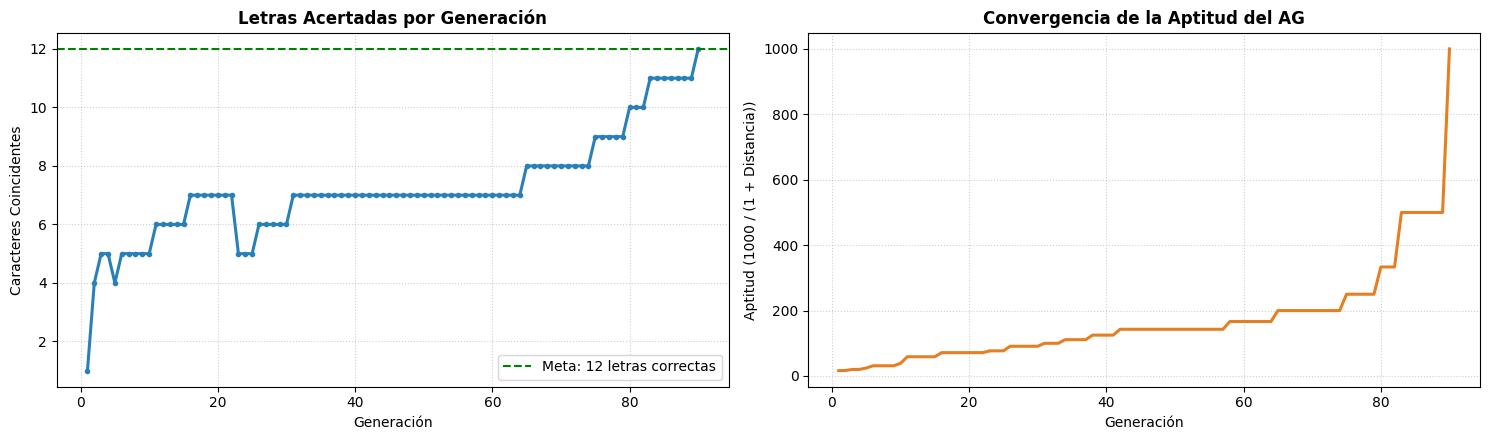

In [10]:
# ==============================================================================
# ALGORITMO GENÉTICO: EVOLUCIÓN DE PALABRAS CON SÍNTESIS DE VOZ
# Ejercicio 3.10 - 5: Población de 50 palabras hacia palabra objetivo
# ==============================================================================

import random
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Javascript, display

# ------------------------------------------------------------------------------
# 1. PARÁMETROS GENERALES Y PALABRA OBJETIVO (FUNCIÓN DE APTITUD)
# ------------------------------------------------------------------------------
# Puedes cambiar esta palabra por cualquier otra que desees evaluar:
PALABRA_OBJETIVO = "INTELIGENCIA"

ALFABETO = " ABCDEFGHIJKLMNOPQRSTUVWXYZ"
LONGITUD = len(PALABRA_OBJETIVO)
K_POBLACION = 50
MAX_GENERACIONES = 200
P_MUTACION = 0.05
TASA_ELITISMO = 0.05  # Conserva los mejores individuos

# ------------------------------------------------------------------------------
# 2. RUTINA DE SÍNTESIS DE VOZ (REPRODUCCIÓN POR PARLANTE EN COLAB)
# ------------------------------------------------------------------------------
def hablar_palabra(texto):
    """
    Reproduce texto por los altavoces del computador usando la API nativa
    de síntesis de voz del navegador Web (JavaScript Web Speech API).
    """
    js_code = f"""
    let utterance = new SpeechSynthesisUtterance('{texto}');
    utterance.lang = 'es-ES';
    utterance.rate = 0.9;
    window.speechSynthesis.speak(utterance);
    """
    display(Javascript(js_code))

# ------------------------------------------------------------------------------
# 3. RUTINAS DEL ALGORITMO GENÉTICO (SECCIONES 3.3, 3.5 Y 3.8)
# ------------------------------------------------------------------------------
def genera_palabra(longitud):
    """Genera aleatoriamente una palabra de longitud L a partir del alfabeto."""
    return "".join(random.choice(ALFABETO) for _ in range(longitud))

def genera_poblacion(K, longitud):
    """Genera la población inicial de K palabras aleatorias."""
    return [genera_palabra(longitud) for _ in range(K)]

def evaluar_palabra(individuo, objetivo):
    """
    Función de Aptitud:
    Calcula la distancia absoluta entre códigos ordinales de caracteres.
    Aptitud máxima cuando Distancia = 0 (coincidencia exacta).
    """
    distancia = sum(abs(ord(c_ind) - ord(c_obj)) for c_ind, c_obj in zip(individuo, objetivo))
    coincidencias = sum(1 for c_ind, c_obj in zip(individuo, objetivo) if c_ind == c_obj)
    aptitud = 1000.0 / (1.0 + distancia)
    return aptitud, coincidencias, distancia

def eval_apt(poblacion, objetivo):
    """Evalúa la aptitud de cada palabra y calcula probabilidades de ruleta."""
    aptitudes = []
    for palabra in poblacion:
        apt, _, _ = evaluar_palabra(palabra, objetivo)
        aptitudes.append(apt)

    apt_total = sum(aptitudes)
    probab = [a / apt_total if apt_total > 0 else 1.0 / len(poblacion) for a in aptitudes]
    return aptitudes, probab

def seleccion(poblacion, probab):
    """Selección por ruleta proporcional."""
    return random.choices(poblacion, weights=probab, k=len(poblacion))

def cruce(padres, longitud):
    """Cruce simple en un punto."""
    hijos = []
    K = len(padres)
    for i in range(0, K - 1, 2):
        p1, p2 = padres[i], padres[i + 1]
        pt = random.randint(1, longitud - 1)
        h1 = p1[:pt] + p2[pt:]
        h2 = p2[:pt] + p1[pt:]
        hijos.append(h1)
        hijos.append(h2)
    if len(hijos) < K:
        hijos.append(padres[-1])
    return hijos

def mutacion(hijos, p_mut):
    """Mutación puntual: reemplaza caracteres aleatorios con probabilidad p_mut."""
    hijos_mutados = []
    for palabra in hijos:
        palabra_lista = list(palabra)
        for idx in range(len(palabra_lista)):
            if random.random() < p_mut:
                palabra_lista[idx] = random.choice(ALFABETO)
        hijos_mutados.append("".join(palabra_lista))
    return hijos_mutados

# ------------------------------------------------------------------------------
# 4. CICLO GENERACIONAL EVOLUTIVO
# ------------------------------------------------------------------------------
def evolucionar_palabras(objetivo, K=50, max_gen=200, p_mut=0.05):
    longitud = len(objetivo)
    poblacion = genera_poblacion(K, longitud)

    num_elites = max(1, int(K * TASA_ELITISMO))
    historial_mejor_apt = []
    historial_coincidencias = []

    # Evaluar generación 0
    aptitudes, _ = eval_apt(poblacion, objetivo)
    mejor_idx = aptitudes.index(max(aptitudes))
    mejor_inicial = poblacion[mejor_idx]

    print("=" * 65)
    print("INICIO DE LA EVOLUCIÓN DE PALABRAS")
    print(f"Palabra objetivo a alcanzar : '{objetivo}' (Longitud: {longitud})")
    print(f"Mejor palabra aleatoria Gen 0: '{mejor_inicial}'")
    print("=" * 65)

    # Reproducir por parlante la primera palabra generada
    print("\n🔊 Reproduciendo por el parlante la mejor palabra inicial...")
    hablar_palabra(f"Palabra inicial: {mejor_inicial}")
    time.sleep(2)  # Pausa breve para permitir la locución

    mejor_global = mejor_inicial
    gen_convergencia = max_gen

    for gen in range(1, max_gen + 1):
        aptitudes, probab = eval_apt(poblacion, objetivo)

        # Ordenar individuos de mayor a menor aptitud
        ordenados = sorted(zip(poblacion, aptitudes), key=lambda x: x[1], reverse=True)
        mejor_actual, mejor_apt = ordenados[0]

        _, aciertos, _ = evaluar_palabra(mejor_actual, objetivo)
        historial_mejor_apt.append(mejor_apt)
        historial_coincidencias.append(aciertos)

        mejor_global = mejor_actual

        if gen % 15 == 0 or mejor_global == objetivo:
            print(f"Gen {gen:3d} | Mejor: '{mejor_global}' | Aciertos: {aciertos}/{longitud} | Aptitud: {mejor_apt:.2f}")

        # Criterio de parada por solución óptima encontrada
        if mejor_global == objetivo:
            gen_convergencia = gen
            print(f"\n ¡Palabra objetivo '{objetivo}' alcanzada exitosamente en la generación {gen}!")
            break

        # Elitismo: pasar los mejores individuos directamente
        nueva_poblacion = [ind for ind, _ in ordenados[:num_elites]]

        # Selección de padres
        padres = seleccion(poblacion, probab)

        # Cruce y Mutación
        hijos = cruce(padres, longitud)
        hijos_mutados = mutacion(hijos, p_mut)

        nueva_poblacion.extend(hijos_mutados[: K - num_elites])
        poblacion = nueva_poblacion

    # Reproducir la palabra objetivo alcanzada
    print("\n🔊 Reproduciendo por el parlante la palabra final alcanzada...")
    hablar_palabra(f"Palabra alcanzada: {mejor_global}")

    return mejor_global, mejor_inicial, historial_mejor_apt, historial_coincidencias, gen_convergencia

# ------------------------------------------------------------------------------
# 5. VISUALIZACIÓN GRÁFICA DE CONVERGENCIA
# ------------------------------------------------------------------------------
def graficar_evolucion(hist_apt, hist_aciertos, longitud, gen_conv):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
    generaciones = range(1, len(hist_apt) + 1)

    # Gráfica 1: Evolución de caracteres correctos
    ax1.plot(generaciones, hist_aciertos, color="#2980b9", linewidth=2.2, marker="o", markersize=3)
    ax1.axhline(y=longitud, color="green", linestyle="--", label=f"Meta: {longitud} letras correctas")
    ax1.set_title("Letras Acertadas por Generación", fontweight="bold")
    ax1.set_xlabel("Generación")
    ax1.set_ylabel("Caracteres Coincidentes")
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend()

    # Gráfica 2: Curva de convergencia de Aptitud (Fitness)
    ax2.plot(generaciones, hist_apt, color="#e67e22", linewidth=2.2)
    ax2.set_title("Convergencia de la Aptitud del AG", fontweight="bold")
    ax2.set_xlabel("Generación")
    ax2.set_ylabel("Aptitud (1000 / (1 + Distancia))")
    ax2.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 6. EJECUCIÓN PRINCIPAL
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    random.seed(42)

    mejor_fin, mejor_ini, h_apt, h_aciertos, g_conv = evolucionar_palabras(
        objetivo=PALABRA_OBJETIVO,
        K=K_POBLACION,
        max_gen=MAX_GENERACIONES,
        p_mut=P_MUTACION
    )

    graficar_evolucion(h_apt, h_aciertos, len(PALABRA_OBJETIVO), g_conv)

# Algoritmos Genéticos Multi-Objetivo (MOGA)
## Ejercicio 3.10 - 6: Optimización de la Dieta con Dos Funciones Objetivo en Conflicto

---

### 1. Formulación del Problema
El problema de la dieta consiste en seleccionar las porciones diarias óptimas de una canasta de alimentos disponibles para satisfacer los requerimientos biológicos de macronutrientes (calorías, proteínas y carbohidratos) al menor costo financiero posible[cite: 7].

A diferencia de los problemas de optimización mono-objetivo, este escenario presenta dos funciones objetivo contrapuestas que no admiten una solución simultáneamente óptima en ambos aspectos[cite: 7]:
1. **Objetivo 1 ($f_1$): Satisfacción de Requerimientos Nutricionales.** Minimizar la discrepancia entre el aporte de la dieta y las metas recomendadas[cite: 7].
2. **Objetivo 2 ($f_2$): Minimización del Costo Económico.** Reducir el gasto presupuestal total diario de la compra de alimentos[cite: 7].

Reducir al extremo el costo monetario conduce a dietas incompletas o de baja calidad biológica; en contraste, cubrir con precisión milimétrica los macros exige combinaciones de alimentos más costosas[cite: 7].

---

### 2. Marco Teórico: Algoritmos Genéticos Multi-Objetivo (MOGA)
Como se detalla en la sección 3.9 del documento guía, cuando se optimizan múltiples objetivos en conflicto se emplean **MOGAs**, cuyo resultado es un conjunto de soluciones óptimas denominado **Frente de Pareto**[cite: 7]:

* **Dominancia de Pareto:** Una dieta candidata $A$ **domina** a otra dieta $B$ ($A \prec B$) si y solo si[cite: 7]:
  * $A$ es igual o mejor que $B$ en todos los objetivos ($f_1(A) \le f_1(B)$ y $f_2(A) \le f_2(B)$)[cite: 7].
  * $A$ es estrictamente superior a $B$ en al menos uno de los objetivos[cite: 7].
* **Frente de Pareto:** Conjunto de soluciones no dominadas[cite: 7]. Representa los mejores compromisos de intercambio (*trade-offs*) entre presupuesto y equilibrio nutricional, permitiendo al tomador de decisiones seleccionar la opción más adecuada a su contexto[cite: 7].

---

### 3. Modelo Matemático

#### Variables de Decisión (Cromosoma / Genotipo)
Vector $X = [x_1, x_2, \dots, x_N]$, donde cada gen $x_i \ge 0$ representa la cantidad de porciones consumidas del alimento $i$[cite: 7].

#### Función Objetivo 1: Discrepancia Nutricional ($f_1$)
Minimizar el error porcentual acumulado frente a las metas diarias de calorías ($M_{\text{cal}}$), proteínas ($M_{\text{prot}}$) y carbohidratos ($M_{\text{carb}}$)[cite: 7]:
$$f_1(X) = \left( \frac{|\text{Cal}(X) - M_{\text{cal}}|}{M_{\text{cal}}} + \frac{|\text{Prot}(X) - M_{\text{prot}}|}{M_{\text{prot}}} + \frac{|\text{Carb}(X) - M_{\text{carb}}|}{M_{\text{carb}}} \right) \times 100$$

#### Función Objetivo 2: Costo Total Diario ($f_2$)
Minimizar el costo económico total de la dieta[cite: 7]:
$$f_2(X) = \sum_{i=1}^N x_i \cdot \text{precio}_i$$

---

### 4. Arquitectura y Operadores Genéticos
* **Población ($K = 80$):** Canastas de dietas evaluadas simultáneamente en cada generación[cite: 7].
* **Criterio de Parada ($M = 120$):** Número de iteraciones evolutivas para consolidar y estabilizar el Frente de Pareto[cite: 7].
* **Selección por Torneo de Pareto:** Se seleccionan progenitores prefiriendo individuos no dominados o con mejor clasificación de compromiso[cite: 7].
* **Cruce Aritmético:** Recombinación lineal de porciones entre parejas de padres ($H_1 = \alpha P_1 + (1-\alpha)P_2$) para explorar gradualmente el espacio de cantidades continuas[cite: 7].
* **Mutación Continua ($p_m = 0.08$):** Perturbaciones aleatorias en las porciones de alimentos para preservar la diversidad y descubrir nuevas combinaciones en el espectro nutricional[cite: 7].
* **Elitismo Multi-Objetivo:** Preservación directa de las soluciones no dominadas en la siguiente generación, asegurando que el frente no pierda los mejores compromisos descubiertos[cite: 7].

         RESULTADOS DE LA DIETA MULTI-OBJETIVO (FRENTE DE PARETO)
Total de soluciones de compromiso en el Frente de Pareto: 26
--------------------------------------------------------------------------------
Opción   | Costo Diario   | Error Nut. (%)  | Calorías   | Proteínas  | Carbos    
--------------------------------------------------------------------------------
Dieta 1  | $     6,995 |        56.56% |   1394.2 |     62.0g |    240.7g
Dieta 2  | $     7,064 |        54.82% |   1406.7 |     62.6g |    241.5g
Dieta 3  | $     7,205 |        51.28% |   1432.5 |     64.0g |    242.7g
Dieta 4  | $     7,400 |        47.46% |   1455.1 |     65.6g |    244.4g
Dieta 5  | $     7,402 |        44.99% |   1475.9 |     65.0g |    249.9g
Dieta 6  | $     7,661 |        41.08% |   1500.3 |     67.9g |    247.6g
Dieta 7  | $     7,716 |        39.77% |   1510.5 |     68.8g |    246.8g
Dieta 8  | $     7,771 |        39.13% |   1517.5 |     68.5g |    248.5g
Dieta 9  | $     7,846 |        37.0

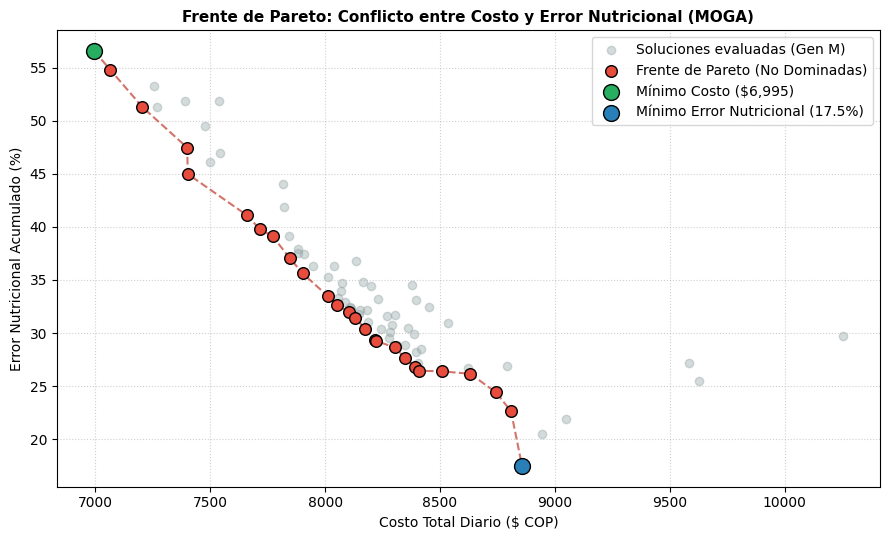

In [11]:
# ==============================================================================
# ALGORITMO GENÉTICO MULTI-OBJETIVO (MOGA): EL PROBLEMA DE LA DIETA
# Ejercicio 3.10 - 6: Optimización simultánea de Satisfacción Nutricional y Costo
# ==============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. TABLA DE ALIMENTOS Y METAS NUTRICIONALES DIARIAS
# ------------------------------------------------------------------------------
# [Alimento, Calorías (kcal), Proteínas (g), Carbohidratos (g), Costo ($/porción)]
TABLA_ALIMENTOS = [
    {"nombre": "Huevos (2 und)",       "cal": 150, "prot": 12, "carb": 1,   "costo": 1200},
    {"nombre": "Arroz blanco (150g)",  "cal": 195, "prot": 4,  "carb": 42,  "costo": 800},
    {"nombre": "Pechuga pollo (150g)", "cal": 220, "prot": 35, "carb": 0,   "costo": 3800},
    {"nombre": "Lentejas (150g)",      "cal": 170, "prot": 13, "carb": 28,  "costo": 1100},
    {"nombre": "Avena (50g)",          "cal": 180, "prot": 6,  "carb": 30,  "costo": 700},
    {"nombre": "Leche entera (250ml)", "cal": 150, "prot": 8,  "carb": 12,  "costo": 1000},
    {"nombre": "Plátano maduro (1 und)", "cal": 110, "prot": 1,  "carb": 28,  "costo": 900},
    {"nombre": "Atún en lata (100g)",  "cal": 130, "prot": 28, "carb": 0,   "costo": 4200}
]

N_ALIMENTOS = len(TABLA_ALIMENTOS)

# Metas nutricionales diarias de referencia
METAS = {
    "calorias": 2000.0,    # kcal
    "proteinas": 80.0,     # gramos
    "carbohidratos": 250.0 # gramos
}

# ------------------------------------------------------------------------------
# 2. EVALUACIÓN DE LAS DOS FUNCIONES OBJETIVO
# ------------------------------------------------------------------------------
def evaluar_dieta(cromosoma):
    """
    Calcula:
    Objetivo 1 (f1): Error acumulado respecto a los requerimientos nutricionales.
    Objetivo 2 (f2): Costo económico total de la dieta en $.
    """
    cal_totales = sum(cromosoma[i] * TABLA_ALIMENTOS[i]["cal"] for i in range(N_ALIMENTOS))
    prot_totales = sum(cromosoma[i] * TABLA_ALIMENTOS[i]["prot"] for i in range(N_ALIMENTOS))
    carb_totales = sum(cromosoma[i] * TABLA_ALIMENTOS[i]["carb"] for i in range(N_ALIMENTOS))
    costo_total = sum(cromosoma[i] * TABLA_ALIMENTOS[i]["costo"] for i in range(N_ALIMENTOS))

    # Discrepancias normalizadas respecto a la meta (%)
    err_cal = abs(cal_totales - METAS["calorias"]) / METAS["calorias"]
    err_prot = abs(prot_totales - METAS["proteinas"]) / METAS["proteinas"]
    err_carb = abs(carb_totales - METAS["carbohidratos"]) / METAS["carbohidratos"]

    error_nutricional = (err_cal + err_prot + err_carb) * 100.0  # Escala porcentual
    return error_nutricional, costo_total, (cal_totales, prot_totales, carb_totales)

# ------------------------------------------------------------------------------
# 3. DOMINANCIA DE PARETO Y CLASIFICACIÓN MOGA
# ------------------------------------------------------------------------------
def domina(sol_a, sol_b):
    """
    Retorna True si la solución A domina a B (minimización en ambos objetivos).
    """
    f1_a, f2_a = sol_a[0], sol_a[1]
    f1_b, f2_b = sol_b[0], sol_b[1]
    es_igual_o_mejor = (f1_a <= f1_b) and (f2_a <= f2_b)
    es_estrictamente_mejor = (f1_a < f1_b) or (f2_a < f2_b)
    return es_igual_o_mejor and es_estrictamente_mejor

def obtener_frente_pareto(poblacion_evaluada):
    """Filtra y extrae el conjunto de soluciones no dominadas (Frente de Pareto)."""
    no_dominados = []
    for i, ind_a in enumerate(poblacion_evaluada):
        es_dominado = False
        for j, ind_b in enumerate(poblacion_evaluada):
            if i != j and domina(ind_b["eval"], ind_a["eval"]):
                es_dominado = True
                break
        if not es_dominado:
            no_dominados.append(ind_a)
    return no_dominados

# ------------------------------------------------------------------------------
# 4. RUTINAS DEL ALGORITMO GENÉTICO (SECCIONES 3.3, 3.5 Y 3.9)
# ------------------------------------------------------------------------------
def genera_poblacion(K):
    """Genera K dietas con porciones reales continuas en [0, 4] por alimento."""
    return [[round(random.uniform(0.0, 4.0), 2) for _ in range(N_ALIMENTOS)] for _ in range(K)]

def seleccion_torneo_pareto(poblacion_evaluada, tam_torneo=3):
    """Selecciona un progenitor prefiriendo individuos no dominados o de menor error compuesto."""
    aspirantes = random.sample(poblacion_evaluada, tam_torneo)
    mejor = aspirantes[0]
    for otro in aspirantes[1:]:
        if domina(otro["eval"], mejor["eval"]):
            mejor = otro
    return mejor["cromosoma"]

def cruce_aritmetico(padre1, padre2):
    """Recombinación lineal de porciones alimentarias."""
    alfa = random.random()
    hijo1 = [round(alfa * padre1[i] + (1 - alfa) * padre2[i], 2) for i in range(N_ALIMENTOS)]
    hijo2 = [round((1 - alfa) * padre1[i] + alfa * padre2[i], 2) for i in range(N_ALIMENTOS)]
    return hijo1, hijo2

def mutacion_continua(hijos, p_mut=0.08):
    """Añade pequeñas variaciones estocásticas a las porciones de comida."""
    for ind in hijos:
        for i in range(N_ALIMENTOS):
            if random.random() < p_mut:
                delta = random.uniform(-0.5, 0.5)
                ind[i] = round(max(0.0, min(5.0, ind[i] + delta)), 2)
    return hijos

# ------------------------------------------------------------------------------
# 5. CICLO EVOLUTIVO MOGA
# ------------------------------------------------------------------------------
def optimizar_dieta_moga(K=80, M=120, p_mut=0.08):
    poblacion = genera_poblacion(K)

    for gen in range(M):
        pob_eval = []
        for crom in poblacion:
            err_nut, costo, stats = evaluar_dieta(crom)
            pob_eval.append({"cromosoma": crom, "eval": (err_nut, costo), "stats": stats})

        nueva_poblacion = []
        # Conservar el frente de Pareto actual (elitismo multiobjetivo)
        frente_actual = obtener_frente_pareto(pob_eval)
        for ind in frente_actual[:max(1, K // 5)]:
            nueva_poblacion.append(list(ind["cromosoma"]))

        while len(nueva_poblacion) < K:
            p1 = seleccion_torneo_pareto(pob_eval)
            p2 = seleccion_torneo_pareto(pob_eval)
            h1, h2 = cruce_aritmetico(p1, p2)
            nueva_poblacion.append(h1)
            if len(nueva_poblacion) < K:
                nueva_poblacion.append(h2)

        poblacion = mutacion_continua(nueva_poblacion, p_mut)

    # Evaluación final de la población convergida
    pob_final_eval = []
    for crom in poblacion:
        err_nut, costo, stats = evaluar_dieta(crom)
        pob_final_eval.append({"cromosoma": crom, "eval": (err_nut, costo), "stats": stats})

    frente_pareto_final = obtener_frente_pareto(pob_final_eval)
    # Ordenar el frente por costo ascendente
    frente_pareto_final.sort(key=lambda x: x["eval"][1])
    return frente_pareto_final, pob_final_eval

# ------------------------------------------------------------------------------
# 6. VISUALIZACIÓN GRÁFICA DEL FRENTE DE PARETO
# ------------------------------------------------------------------------------
def graficar_frente_pareto(frente, poblacion_total):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    # 1. Toda la población evaluada en la última generación
    costos_pob = [ind["eval"][1] for ind in poblacion_total]
    errores_pob = [ind["eval"][0] for ind in poblacion_total]
    ax.scatter(costos_pob, errores_pob, color="#95a5a6", alpha=0.4, label="Soluciones evaluadas (Gen M)")

    # 2. Soluciones No Dominadas (Frente de Pareto)
    costos_pareto = [ind["eval"][1] for ind in frente]
    errores_pareto = [ind["eval"][0] for ind in frente]
    ax.plot(costos_pareto, errores_pareto, color="#c0392b", linestyle="--", alpha=0.7)
    ax.scatter(costos_pareto, errores_pareto, color="#e74c3c", s=70, edgecolors="black",
               label="Frente de Pareto (No Dominadas)", zorder=4)

    # Destacar extremos: Dieta Económica vs Dieta Nutricionalmente Precisa
    dieta_barata = frente[0]
    dieta_precisa = min(frente, key=lambda x: x["eval"][0])

    ax.scatter([dieta_barata["eval"][1]], [dieta_barata["eval"][0]], color="#27ae60", s=130,
               edgecolors="black", label=f"Mínimo Costo (${dieta_barata['eval'][1]:,.0f})", zorder=5)
    ax.scatter([dieta_precisa["eval"][1]], [dieta_precisa["eval"][0]], color="#2980b9", s=130,
               edgecolors="black", label=f"Mínimo Error Nutricional ({dieta_precisa['eval'][0]:.1f}%)", zorder=5)

    ax.set_title("Frente de Pareto: Conflicto entre Costo y Error Nutricional (MOGA)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Costo Total Diario ($ COP)", fontsize=10)
    ax.set_ylabel("Error Nutricional Acumulado (%)", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 7. EJECUCIÓN PRINCIPAL Y REPORTE DE RESULTADOS
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    random.seed(42)
    np.random.seed(42)

    frente, pob_total = optimizar_dieta_moga(K=80, M=120, p_mut=0.08)

    print("=" * 80)
    print("         RESULTADOS DE LA DIETA MULTI-OBJETIVO (FRENTE DE PARETO)")
    print("=" * 80)
    print(f"Total de soluciones de compromiso en el Frente de Pareto: {len(frente)}")
    print("-" * 80)
    print(f"{'Opción':<8} | {'Costo Diario':<14} | {'Error Nut. (%)':<15} | {'Calorías':<10} | {'Proteínas':<10} | {'Carbos':<10}")
    print("-" * 80)

    for idx, ind in enumerate(frente):
        err, costo = ind["eval"]
        cal, prot, carb = ind["stats"]
        print(f"Dieta {idx+1:<2} | ${costo:>10,.0f} | {err:>12.2f}% | {cal:>8.1f} | {prot:>8.1f}g | {carb:>8.1f}g")

    print("-" * 80)
    print("Metas recomendadas diarias : 2000.0 kcal | 80.0g Proteína | 250.0g Carbohidratos")
    print("=" * 80)

    # Composición de la dieta balanceada central
    dieta_media = frente[len(frente) // 2]
    print("\nDesglose de porciones para la dieta intermedia del Frente de Pareto:")
    for i, cant in enumerate(dieta_media["cromosoma"]):
        if cant > 0.05:
            print(f" - {TABLA_ALIMENTOS[i]['nombre']:<25}: {cant:.2f} porciones")

    graficar_frente_pareto(frente, pob_total)